# EDA — B2W-Reviews01 com intenções derivadas

Este notebook documenta a análise exploratória do dataset escolhido para o domínio de atendimento de e-commerce. A fonte, a licença, as decisões de limpeza e a taxonomia estão descritas no [README](../README.md).

> **Importante:** B2W-Reviews01 não possui intenções humanas. `intent` representa o tema principal, enquanto `sentiment` registra o tom separadamente; os campos de proveniência tornam ambas as inferências auditáveis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start_path: Path) -> Path:
    for candidate in (start_path, *start_path.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('pyproject.toml não foi encontrado.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'b2w_reviews_intents.parquet'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'{DATA_PATH} não existe. Execute primeiro scripts/build_b2w_intent_dataset.py.'
    )

print(f'Dataset: {DATA_PATH.relative_to(PROJECT_ROOT)}')

Dataset: data/processed/b2w_reviews_intents.parquet


In [2]:
df = pd.read_parquet(DATA_PATH)
df['submission_date'] = pd.to_datetime(df['submission_date'], errors='coerce')
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print(f'Shape: {df.shape}')
print('\nDtypes:')
display(df.dtypes.rename('dtype').to_frame())
print('\nResumo descritivo:')
display(df.describe(include='all').T)
display(df.head(3))

Shape: (131307, 16)

Dtypes:


,dtype
dataset_version,object
source_row_id,int64
submission_date,datetime64[ns]
product_id,string[python]
product_category,object
product_subcategory,object
overall_rating,int8
recommend_to_a_friend,object
text,object
intent,object



Resumo descritivo:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
dataset_version,131307,1,b2w-reviews01-intents-v4,131307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_row_id,131307.0,NaN,NaN,NaN,65832.351634,0.0,32853.5,65726.0,98596.5,132372.0,38108.024228
submission_date,131307,NaN,NaN,NaN,2018-03-16 13:19:47.000243712,2018-01-01 00:11:28,2018-01-28 17:07:09,2018-03-21 16:21:04,2018-04-23 14:44:56.500000,2018-05-31 23:50:33,NaN
product_id,131307,47963,132444092,790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,131301,54,Celulares e Smartphones,20651,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_subcategory,127331,713,Smartphone,17520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overall_rating,131307.0,NaN,NaN,NaN,3.503911,1.0,2.0,4.0,5.0,5.0,1.525016
recommend_to_a_friend,131289,2,Yes,96032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,131307,129405,Gostei muito do produto .. Entrega super rápid...,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intent,131307,23,avaliacao_geral,54932,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,dataset_version,source_row_id,submission_date,product_id,product_category,product_subcategory,overall_rating,recommend_to_a_friend,text,intent,intent_matches,label_source,sentiment,sentiment_source,text_length,word_count
0,b2w-reviews01-intents-v4,0,2018-01-01 00:11:28,132532965,Informática,Notebook,4,Yes,Bom. Estou contente com a compra entrega rápid...,troca_devolucao,troca_devolucao|entrega_antecipada,keyword_heuristic_v4,positivo,rating_fallback_v1,162,28
1,b2w-reviews01-intents-v4,1,2018-01-01 00:13:48,22562178,Utilidades Domésticas,"Copos, Taças e Canecas",4,Yes,"Preço imbatível, ótima qualidade. Por apenas R...",qualidade_produto,qualidade_produto,keyword_heuristic_v4,positivo,keyword_heuristic_v1,102,14
2,b2w-reviews01-intents-v4,2,2018-01-01 00:26:02,113022329,Eletroportáteis,Panela Elétrica,4,Yes,ATENDE TODAS AS EXPECTATIVA.. SUPERA EM AGILID...,uso_desempenho,uso_desempenho,keyword_heuristic_v4,positivo,keyword_heuristic_v1,258,39


In [3]:
missing = pd.DataFrame({
    'valores_ausentes': df.isna().sum(),
    'percentual_ausente': (df.isna().mean() * 100).round(2),
})

duplicate_count = df.duplicated().sum()
empty_text_count = df["text"].fillna("").str.strip().eq("").sum()
multi_intent_count = df["intent_matches"].fillna("").str.contains(r"\|").sum()
print(f'Duplicatas exatas: {duplicate_count:,}')
print(f'Textos vazios: {empty_text_count:,}')
print(f'Linhas com múltiplas intenções textuais: {multi_intent_count:,}')
display(missing)

# Decisão de qualidade: duplicatas e texto vazio devem ser zero após a limpeza.
assert duplicate_count == 0
assert df['text'].fillna('').str.strip().ne('').all()

Duplicatas exatas: 0
Textos vazios: 0
Linhas com múltiplas intenções textuais: 22,695


,valores_ausentes,percentual_ausente
dataset_version,0,0.00
source_row_id,0,0.00
submission_date,0,0.00
product_id,0,0.00
product_category,6,0.00
product_subcategory,3976,3.03
overall_rating,0,0.00
recommend_to_a_friend,18,0.01
text,0,0.00
intent,0,0.00


In [4]:
intent_summary = df['intent'].value_counts().rename_axis('intent').reset_index(name='registros')
intent_summary['percentual'] = (intent_summary['registros'] / len(df) * 100).round(2)
source_summary = df['label_source'].value_counts().rename_axis('label_source').reset_index(name='registros')
source_summary['percentual'] = (source_summary['registros'] / len(df) * 100).round(2)
sentiment_summary = df['sentiment'].value_counts().rename_axis('sentiment').reset_index(name='registros')
sentiment_summary['percentual'] = (sentiment_summary['registros'] / len(df) * 100).round(2)

print(f'Quantidade de categorias: {df["intent"].nunique()}')
display(intent_summary)
display(source_summary)
display(sentiment_summary)

Quantidade de categorias: 23


,intent,registros,percentual
0,avaliacao_geral,54932,41.83
1,qualidade_produto,14094,10.73
2,atraso_entrega,12141,9.25
3,entrega_antecipada,10518,8.01
4,custo_beneficio,7187,5.47
5,uso_desempenho,4990,3.80
6,tamanho_dimensoes,4874,3.71
7,produto_defeituoso,4476,3.41
8,entrega_no_prazo,4186,3.19
9,troca_devolucao,3641,2.77


,label_source,registros,percentual
0,keyword_heuristic_v4,76375,58.17
1,generic_topic_fallback_v1,54932,41.83


,sentiment,registros,percentual
0,positivo,85854,65.38
1,negativo,31236,23.79
2,neutro,11270,8.58
3,misto,2947,2.24


## Visualizações

Os gráficos abaixo cobrem distribuição de temas, sentimentos, extensão das mensagens, proveniência dos rótulos e relação entre nota e tema. Todas as agregações são feitas com Pandas antes da visualização.

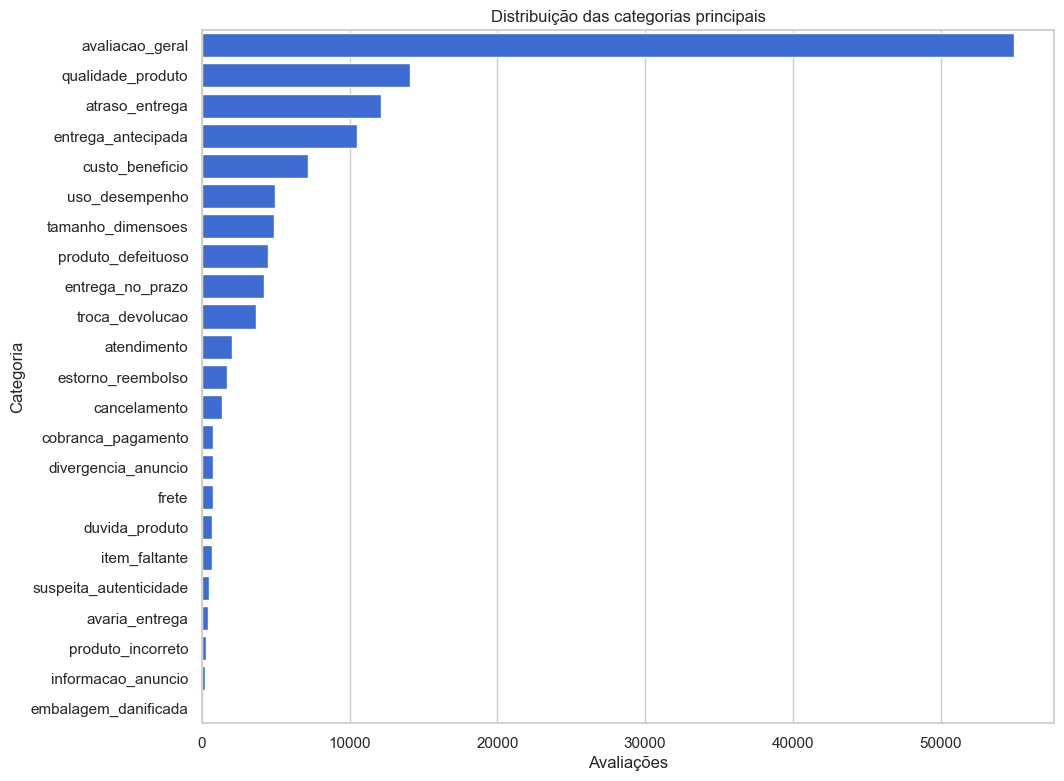

In [5]:
# 1. Gráfico de barras: distribuição das categorias principais
plt.figure(figsize=(11, 9))
sns.barplot(data=intent_summary, y='intent', x='registros', color='#2563EB')
plt.title('Distribuição das categorias principais')
plt.xlabel('Avaliações')
plt.ylabel('Categoria')
plt.show()

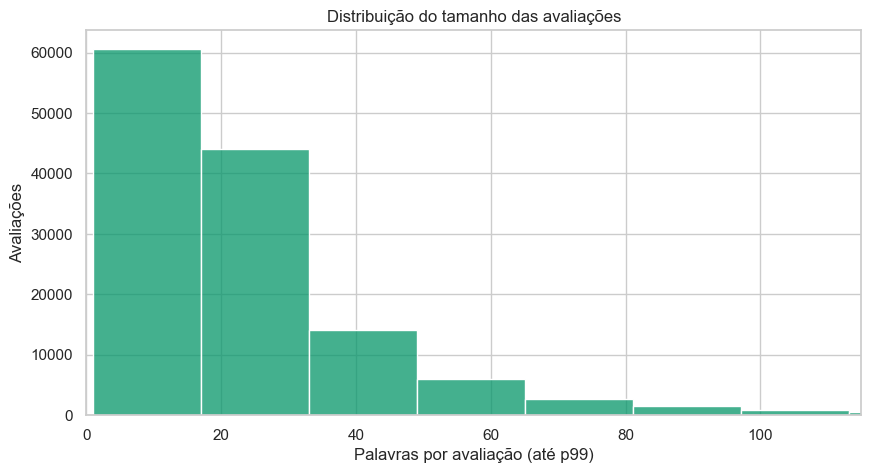

In [6]:
# 2. Histograma: tamanho das mensagens
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='word_count', bins=50, color='#059669', edgecolor='white')
plt.xlim(0, df['word_count'].quantile(0.99))
plt.title('Distribuição do tamanho das avaliações')
plt.xlabel('Palavras por avaliação (até p99)')
plt.ylabel('Avaliações')
plt.show()

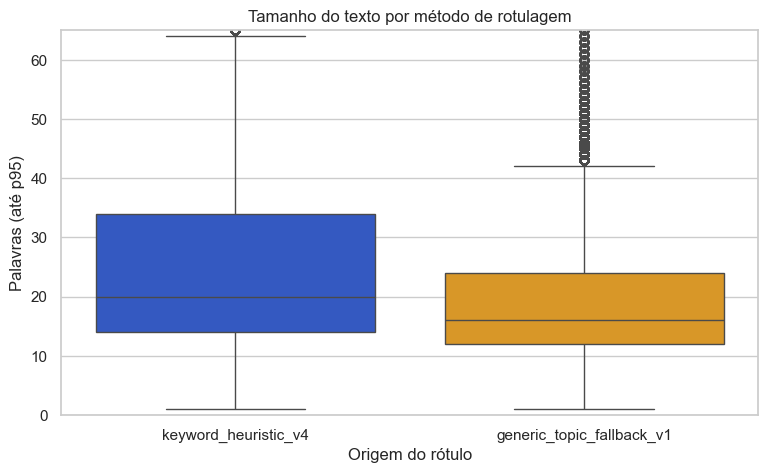

In [7]:
# 3. Boxplot: extensão do texto por origem do rótulo
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='label_source', y='word_count', hue='label_source', palette={'keyword_heuristic_v4': '#1D4ED8', 'generic_topic_fallback_v1': '#F59E0B'}, legend=False)
plt.ylim(0, df['word_count'].quantile(0.95))
plt.title('Tamanho do texto por método de rotulagem')
plt.xlabel('Origem do rótulo')
plt.ylabel('Palavras (até p95)')
plt.show()

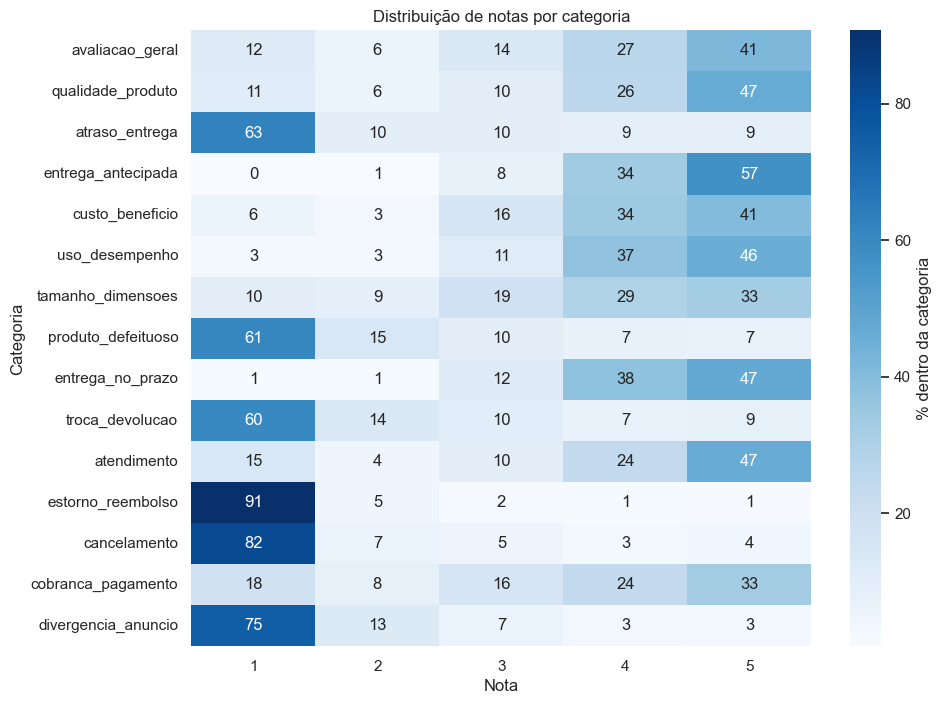

In [8]:
# 4. Heatmap: distribuição das notas dentro das 15 categorias mais frequentes
top_intents = intent_summary.head(15)['intent'].tolist()
rating_by_intent = (
    pd.crosstab(df['intent'], df['overall_rating'], normalize='index')
    .mul(100)
    .reindex(top_intents)
)
plt.figure(figsize=(10, 8))
sns.heatmap(rating_by_intent, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% dentro da categoria'})
plt.title('Distribuição de notas por categoria')
plt.xlabel('Nota')
plt.ylabel('Categoria')
plt.show()

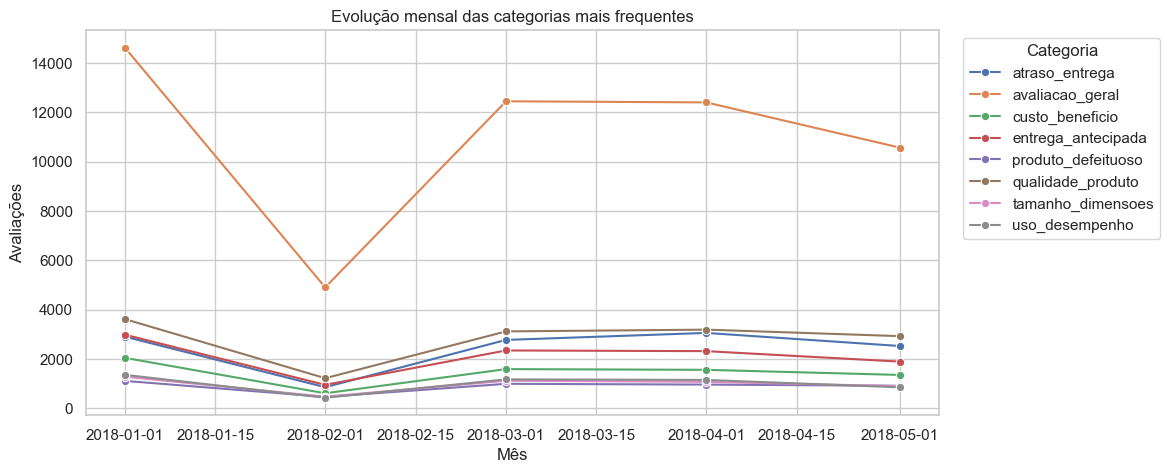

In [9]:
# 5. Série temporal: categorias mais frequentes por mês
monthly = (
    df.dropna(subset=['submission_date'])
    .loc[lambda data: data['intent'].isin(top_intents[:8])]
    .assign(month=lambda data: data['submission_date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['month', 'intent'])
    .size()
    .rename('registros')
    .reset_index()
)
plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly, x='month', y='registros', hue='intent', marker='o')
plt.title('Evolução mensal das categorias mais frequentes')
plt.xlabel('Mês')
plt.ylabel('Avaliações')
plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

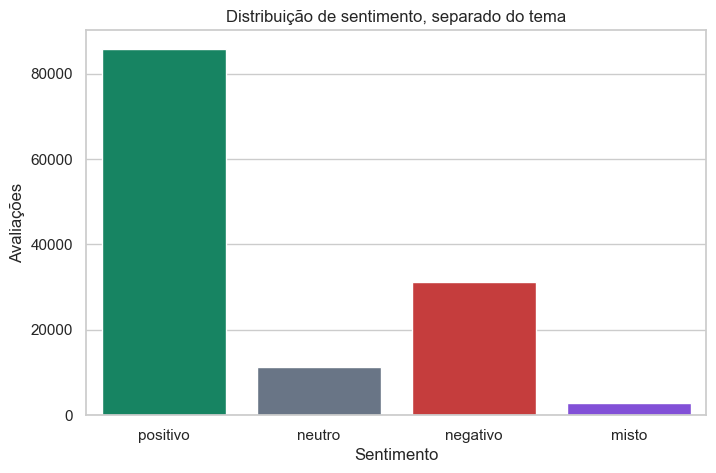

In [10]:
# 6. Gráfico de barras: sentimento separado do tema
sentiment_order = ['positivo', 'neutro', 'negativo', 'misto']
sentiment_plot = sentiment_summary.set_index('sentiment').reindex(sentiment_order, fill_value=0).reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=sentiment_plot, x='sentiment', y='registros', hue='sentiment', palette={'positivo': '#059669', 'neutro': '#64748B', 'negativo': '#DC2626', 'misto': '#7C3AED'}, legend=False)
plt.title('Distribuição de sentimento, separado do tema')
plt.xlabel('Sentimento')
plt.ylabel('Avaliações')
plt.show()

## Hipóteses orientadas pelos dados

As hipóteses abaixo são pontos de investigação, não conclusões causais. Elas são recalculadas com as contagens do dataset carregado.

In [11]:
def category_count(name: str) -> int:
    return int(intent_summary.loc[intent_summary['intent'].eq(name), 'registros'].iloc[0])

hypotheses = pd.DataFrame([
    {
        'hipotese': 'Logística é uma fonte central de fricção e satisfação.',
        'evidencia': f"atraso_entrega: {category_count('atraso_entrega'):,}; entrega_antecipada: {category_count('entrega_antecipada'):,}; entrega_no_prazo: {category_count('entrega_no_prazo'):,}.",
        'como_validar': 'Revisar amostra estratificada e comparar prazo prometido versus prazo real, se esse dado for disponibilizado.'
    },
    {
        'hipotese': 'Qualidade e desempenho são os principais temas pós-compra do produto.',
        'evidencia': f"qualidade_produto: {category_count('qualidade_produto'):,}; uso_desempenho: {category_count('uso_desempenho'):,}; produto_defeituoso: {category_count('produto_defeituoso'):,}.",
        'como_validar': 'Cruzar categorias de produto com taxa de defeito e revisar falsos positivos das regras.'
    },
    {
        'hipotese': 'Parte relevante das avaliações exige reconhecimento de mais de um tema.',
        'evidencia': f"{multi_intent_count:,} textos ativaram mais de um tema; sentimentos não entram nessa contagem.",
        'como_validar': 'Avaliar um classificador multi-label e medir anotação humana em casos com múltiplos temas.'
    },
    {
        'hipotese': 'Uma parcela relevante das avaliações não expressa tema operacional específico.',
        'evidencia': f"{(df['label_source'] == 'generic_topic_fallback_v1').sum():,} registros ({(df['label_source'] == 'generic_topic_fallback_v1').mean() * 100:.2f}%) ficaram como avaliacao_geral.",
        'como_validar': 'Anotar manualmente uma amostra de avaliacao_geral para decidir se novas categorias ou regras são necessárias.'
    },
])
display(hypotheses)

,hipotese,evidencia,como_validar
0,Logística é uma fonte central de fricção e sat...,"atraso_entrega: 12,141; entrega_antecipada: 10...",Revisar amostra estratificada e comparar prazo...
1,Qualidade e desempenho são os principais temas...,"qualidade_produto: 14,094; uso_desempenho: 4,9...",Cruzar categorias de produto com taxa de defei...
2,Parte relevante das avaliações exige reconheci...,"22,695 textos ativaram mais de um tema; sentim...",Avaliar um classificador multi-label e medir a...
3,Uma parcela relevante das avaliações não expre...,"54,932 registros (41.83%) ficaram como avaliac...",Anotar manualmente uma amostra de avaliacao_ge...


## Conclusão

A base final possui texto, categoria principal e proveniência do rótulo em mais de 500 amostras, atendendo ao domínio de atendimento ao cliente. Antes de usar as intenções para avaliar um modelo, a recomendação é criar uma amostra anotada por humanos e comparar as regras contra essa referência.